# Ad'Impact: Statistical A/B Testing on Marketing Conversion
###  *Hypothesis to Business Decision*

## Project Phases
1. Setup & Data Sourcing
2. Business Framing & Hypotheses
3. Data Quality & Sample Ratio Mismatch (SRM) Check
4. Frequentist Hypothesis Testing
5. Bayesian A/B Testing
6. Segment Analysis & Multiple-Testing Correction
7. Power Analysis & Minimum Detectable Effect
8. CTR Extension (second dataset)
9. Results Dashboard & Business Translation
10. Q&A




#Phase 1: Setup & Data Sourcing

### Dataset: Calling Kaggle API




In [2]:
import os
from google.colab import userdata
from google.colab.userdata import SecretNotFoundError

try:
    os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')
    print("KAGGLE_API_TOKEN successfully loaded from Colab secrets.")
except SecretNotFoundError:
    print("Secret 'KAGGLE_API_TOKEN' not found in Colab secrets.")
    print("Please add it via the 'Secrets' tab (key icon) on the left sidebar,")
    print("or proceed to the next cell to upload your 'kaggle.json' file instead.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

KAGGLE_API_TOKEN successfully loaded from Colab secrets.


In [3]:
# Install Kaggle and download the dataset
!pip install kaggle --quiet
!kaggle datasets download -d faviovaz/marketing-ab-testing
!unzip -o marketing-ab-testing.zip
print('Dataset downloaded and unzipped')

Dataset URL: https://www.kaggle.com/datasets/faviovaz/marketing-ab-testing
License(s): CC0-1.0
100% 5.23M/5.23M [00:00<00:00, 77.7MB/s]

Archive:  marketing-ab-testing.zip
  inflating: marketing_AB.csv        
Dataset downloaded and unzipped


In [4]:
#Imports Libry
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.stats.proportion as sms
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
CONTROL_COLOR = '#6c757d'   # PSA (control)
VARIANT_COLOR = '#fd7e14'   # Ad (variant)
PALETTE = [CONTROL_COLOR, VARIANT_COLOR]
ACCENT  = '#0d6efd'

np.random.seed(42)
print('✅ Libraries loaded')

✅ Libraries loaded


In [5]:
# Load the dataset
df = pd.read_csv('marketing_AB.csv')

# Drop the redundant index column in Kaggle exports
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Standardise column names (the raw file uses spaces)
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]

print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(10)

Shape: 588,101 rows × 6 columns


,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14
5,1137664,ad,False,734,Saturday,10
6,1116205,ad,False,264,Wednesday,13
7,1496843,ad,False,17,Sunday,18
8,1448851,ad,False,21,Tuesday,19
9,1446284,ad,False,142,Monday,14


### Schema & Data Quality Checks

Before any statistical test, we verify four things: data types are sane,
there are no missing values, no user appears twice (which would break the
independence assumption every test below relies on), and the group labels
are exactly what we expect.

In [6]:
#Data types & non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   user_id        588101 non-null  int64 
 1   test_group     588101 non-null  object
 2   converted      588101 non-null  bool  
 3   total_ads      588101 non-null  int64 
 4   most_ads_day   588101 non-null  object
 5   most_ads_hour  588101 non-null  int64 
dtypes: bool(1), int64(3), object(2)
memory usage: 23.0+ MB


In [7]:
#Missing values check
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'None — clean dataset ✅')

Missing values per column:
None — clean dataset ✅


In [8]:
#Duplicate user check
n_total = len(df)
n_unique_users = df['user_id'].nunique()
n_duplicates = n_total - n_unique_users

print(f'Total rows          : {n_total:,}')
print(f'Unique user IDs      : {n_unique_users:,}')
print(f'Duplicate user rows  : {n_duplicates:,}')

if n_duplicates == 0:
    print('\n✅ Every user appears exactly once — independence assumption holds.')
else:
    print('\n⚠️  Duplicate users detected — investigate before proceeding to testing.')

Total rows          : 588,101
Unique user IDs      : 588,101
Duplicate user rows  : 0

✅ Every user appears exactly once — independence assumption holds.


:

In [9]:
#Group label check
print("Unique values in 'test_group':", df['test_group'].unique())
print("Unique values in 'converted'  :", df['converted'].unique())
print()
print('Group counts:')
print(df['test_group'].value_counts())
print()
print('Group proportions:')
print((df['test_group'].value_counts(normalize=True) * 100).round(2))

Unique values in 'test_group': ['ad' 'psa']
Unique values in 'converted'  : [False  True]

Group counts:
test_group
ad     564577
psa     23524
Name: count, dtype: int64

Group proportions:
test_group
ad     96.0
psa     4.0
Name: proportion, dtype: float64


In [10]:
df.isnull().sum()

,0
user_id,0
test_group,0
converted,0
total_ads,0
most_ads_day,0
most_ads_hour,0


In [11]:
n_total = len(df)
n_unique_users = df['user_id'].nunique()
n_duplicates = n_total - n_unique_users

print(f'Total rows: {n_total}')
print(f'Unique user IDs: {n_unique_users}')
print(f'Duplicate rows: {n_duplicates}')

Total rows: 588101
Unique user IDs: 588101
Duplicate rows: 0


##Phase 2: Business Framing & Hypotheses

### The Business Question
Does showing users an ad (instead of a neutral Public Service Announcement)
increase the likelihood that they convert? This experiment directly informs
a go/no-go decision: should the company roll the ad out to its full user
base, or keep running the PSA?

### Formal Hypotheses
Let *p₍ad₎* denote the true population conversion rate for users shown the
ad, and *p₍psa₎* denote the true population conversion rate for users shown
the PSA.

- **H₀ (null):** p₍ad₎ = p₍psa₎ — there is no difference in conversion rate
  between the ad group and the PSA group; any observed difference is
  attributable to random sampling noise.
- **H₁ (alternative):** p₍ad₎ > p₍psa₎ — the ad group has a strictly higher
  conversion rate than the PSA group.

### Test Directionality: One-Tailed
This is deliberately framed as a **one-tailed test**, not a two-tailed one.
The PSA functions as the do-nothing baseline; the ad is the variant the
business is actively paying to run, on the hypothesis that it improves
conversion. The only decision this experiment informs is whether to roll
the ad out wider — and that decision only changes if the ad performs
*better*. If the ad underperformed, the resulting action is identical
either way: don't roll it out. Concentrating statistical power into
detecting "is it better," rather than splitting it across "better or
worse," matches the actual decision being made.

### Overall Evaluation Criterion (OEC)
The OEC is the **raw conversion rate** — the proportion of users in each
group whose `converted` value is `True`  compared exactly as randomized,
with no adjustment for `total_ads`.

This is a deliberate choice, not an oversight: `total_ads` is generated
*during* the experiment, downstream of group assignment, rather than being
a pre-existing user characteristic. Adjusting the primary metric for a
post-treatment variable like this risks introducing bias into the
comparison rather than removing it. `total_ads` remains valuable later, as
a segmentation variable in Phase 4 and not just as an adjustment to the
primary success metric.

##Phase 3: Sample Ratio Mismatch Check

SRM check compares the data against the ratio the expected and the actaul.

Part A: the naive assumption test. Many people's default mental model of an A/B test is "50/50 split." Let's formally test the observed data against that assumption, using a chi-square goodness-of-fit test. If you assumed 50/50 was the design and ran this test, clearly 96/4 is nowhere near 50/50  but we want the formal statistical confirmation.

In [12]:
from scipy import stats

# Observed counts, pulled directly from the dataframe (not hardcoded —
# if the data ever changes, this stays correct automatically)
group_counts = df['test_group'].value_counts()
f_obs = [group_counts['ad'], group_counts['psa']]

# Expected counts under the naive assumption being tested: a 50/50 split
n_total = df.shape[0]
f_exp = [n_total * 0.5, n_total * 0.5]

chi2_stat, p_value = stats.chisquare(f_obs=f_obs, f_exp=f_exp)

print(f'Observed        : ad={f_obs[0]:,}, psa={f_obs[1]:,}')
print(f'Expected (50/50): ad={f_exp[0]:,.0f}, psa={f_exp[1]:,.0f}')
print(f'Chi-square statistic: {chi2_stat:,.2f}')
print(f'p-value: {p_value:.2e}')

Observed        : ad=564,577, psa=23,524
Expected (50/50): ad=294,050, psa=294,050
Chi-square statistic: 497,768.83
p-value: 0.00e+00


A chi-square statistic of ~497,769 is enormous, and the p-value rounding to 0.00e+00 doesn't mean the probability is literally zero,it means it's so astronomically small

Part B: is the data consistent with what's more plausibly the real intended design — a 96/4 split, not 50/50? This is where it gets genuinely interesting, because at a sample size of 588,101, even a tiny, practically meaningless deviation from an exact 96.00/4.00 split could come back as "statistically significant"

In [13]:
# ─── SRM Check: Designed 96/4 Assumption Test ──────────────────────────
from scipy import stats

# Same observed counts as before
group_counts = df['test_group'].value_counts()
f_obs = [group_counts['ad'], group_counts['psa']]

# Expected counts under the assumption the experiment was deliberately
# designed for a 96% / 4% split, not 50/50
n_total = df.shape[0]
f_exp = [n_total * 0.96, n_total * 0.04]

chi2_stat, p_value = stats.chisquare(f_obs=f_obs, f_exp=f_exp)

print(f'Observed       : ad={f_obs[0]:,}, psa={f_obs[1]:,}')
print(f'Expected (96/4): ad={f_exp[0]:,.2f}, psa={f_exp[1]:,.2f}')
print(f'Chi-square statistic: {chi2_stat:.4f}')
print(f'p-value: {p_value:.4f}')

Observed       : ad=564,577, psa=23,524
Expected (96/4): ad=564,576.96, psa=23,524.04
Chi-square statistic: 0.0000
p-value: 0.9998


This result is even cleaner than I expected, as tiny deviation might come back significant given how huge the sample is. A chi-square statistic indistinguishable from zero and a p-value of 0.9998. It means if the true design really was exactly 96.00%/4.00%, you'd expect to see deviation at least this small (or smaller) about 99.98% of the time from pure random sampling. In other words, this data is entirely unsurprising under a 96/4

### A Note on Scope
A complete SRM check compares observed data against the ratio the
expected and the actaul. True intended
ratio is not independently known. What follows demonstrates the
methodology rigorously and reasons carefully from the evidence available,
rather than assuming.

### Part A — Testing Against a Naive 50/50 Assumption
A chi-square goodness-of-fit test was run comparing the observed group
counts (564,577 `ad` / 23,524 `psa`) against the counts expected under a
50/50 split.

- **Chi-square statistic:** 497,768.83
- **p-value:** < 1 × 10⁻³⁰⁸ (effectively zero)

**Verdict:** decisively rejected. If the experiment had been designed for
a 50/50 split, a result this imbalanced is statistically near-impossible
to attribute to chance.

### Part B — Testing Against a Designed 96/4 Assumption
The same test was repeated, this time comparing observed counts against
the counts expected under a deliberate 96/4 allocation.

- **Expected:** ad = 564,576.96, psa = 23,524.04
- **Chi-square statistic:** 0.0000
- **p-value:** 0.9998

**Verdict:** not rejected. The observed split matches an exact 96.00%/4.00%
design almost precisely — the deviation is a rounding error, not a
meaningful discrepancy.

Taken together with Phase 0's findings (clean schema, zero missing values,
zero duplicate users), there is **no statistical evidence of a broken
randomization. The 96/4 imbalance is real, but it is consistent with a clean, deliberately-configured allocation rather than a data quality failure.

**Caveat:** This conclusion shows the data is *internally consistent* with
a 96/4 design — it does not independently confirm that ratio was the
platform's actual target. This limitation is noted explicitly rather
than glossed over.



##Phase 4: Frequentis Hypothesis Testing

In [14]:
from statsmodels.stats.proportion import proportions_ztest

# Conversion counts and totals per group
# (.sum() on a boolean column counts the True values, since True == 1)
ad_conversions = df[df['test_group'] == 'ad']['converted'].sum()
ad_total = df[df['test_group'] == 'ad'].shape[0]

psa_conversions = df[df['test_group'] == 'psa']['converted'].sum()
psa_total = df[df['test_group'] == 'psa'].shape[0]

# Two-proportion z-test, one-tailed: H1 is p_ad > p_psa
# 'larger' tests whether count[0]/nobs[0] is significantly greater than
# count[1]/nobs[1] — matching our Phase 1 hypothesis exactly
count = [ad_conversions, psa_conversions]
nobs = [ad_total, psa_total]

z_stat, p_value = proportions_ztest(count=count, nobs=nobs, alternative='larger')

print(f'Ad conversions   : {ad_conversions:,} / {ad_total:,}  ({ad_conversions/ad_total*100:.3f}%)')
print(f'PSA conversions  : {psa_conversions:,} / {psa_total:,}  ({psa_conversions/psa_total*100:.3f}%)')
print(f'Z-statistic      : {z_stat:.4f}')
print(f'p-value          : {p_value:.6f}')

Ad conversions   : 14,423 / 564,577  (2.555%)
PSA conversions  : 420 / 23,524  (1.785%)
Z-statistic      : 7.3701
p-value          : 0.000000



### The Test
A two-proportion z-test was used to compare conversion rates between the
`ad` and `psa` groups, testing the formal hypotheses defined in Phase 1.
Since H₁ specifies a direction (p₍ad₎ > p₍psa₎), the test was run
one-tailed (`alternative='larger'`).

### Results

| Group | Conversions | Total Users | Conversion Rate |
|---|---|---|---|
| Ad  | 14,423 | 564,577 | 2.555% |
| PSA | 420    | 23,524  | 1.785% |

- **Z-statistic:** 7.3701
- **p-value:** < 0.000001 (effectively zero, beyond standard
  floating-point display precision)

**Decision:** reject H₀ at α = 0.05.

### Interpreting the p-value
If there were truly no difference in conversion rate between the ad and
PSA groups, the probability of observing a gap at least as large as the
one found here — specifically with the ad group outperforming the PSA
group — is vanishingly small. This is not the same claim as "there is a
99.9999% probability the ad works"; the p-value says nothing about the
probability of either hypothesis being true, only how surprising this
data would be under H₀.

### Quantifying the Lift
A p-value alone does not tell a stakeholder how large the effect is, only
that it's unlikely to be noise. Both framings are reported together
rather than selecting one, since either alone risks misleading a reader:

- **Absolute lift:** 0.77 percentage points (2.555% − 1.785%)
- **Relative lift:** 43.1% improvement over the PSA baseline

Leading with the relative figure alone would overstate the result, since
it is amplified by a small baseline rate. Leading with the absolute
figure alone understates how large the proportional improvement actually
is. Reporting both gives a complete, honest picture.



## Confidence Interval

In [15]:
from scipy.stats import norm
import numpy as np

# Conversion rates
p_ad  = ad_conversions / ad_total
p_psa = psa_conversions / psa_total
diff  = p_ad - p_psa

# Standard error of the difference between two proportions
SE = np.sqrt((p_ad * (1 - p_ad) / ad_total) + (p_psa * (1 - p_psa) / psa_total))

# Z-critical value for one-tailed 95% CI
z_crit = norm.ppf(0.95)  # = 1.645

# Confidence interval around the lift
margin = z_crit * SE
lower  = diff - margin
upper  = diff + margin

print(f'Conversion rate (ad)  : {p_ad*100:.3f}%')
print(f'Conversion rate (psa) : {p_psa*100:.3f}%')
print(f'Absolute lift         : {diff*100:.4f}pp')
print(f'Z-critical value      : {z_crit:.3f}')
print(f'Standard Error        : {SE:.6f}')
print(f'95% CI (one-tailed)   : [{lower*100:.4f}pp, {upper*100:.4f}pp]')

Conversion rate (ad)  : 2.555%
Conversion rate (psa) : 1.785%
Absolute lift         : 0.7692pp
Z-critical value      : 1.645
Standard Error        : 0.000889
95% CI (one-tailed)   : [0.6231pp, 0.9154pp]


The confidence interval [0.6231pp, 0.9154pp] — this is the most business-relevant number in the whole phase. Read it as: "our best estimate of the true lift is 0.77pp, but accounting for sampling uncertainty, the true effect plausibly sits anywhere between 0.62pp and 0.92pp." The critical thing: the lower bound is 0.62pp, which is above zero — even at the pessimistic end of the plausible range, the ad is still outperforming the PSA. That's a stronger statement than just "p < 0.05."

 ## Phase 5: Bayesian A/B Testing.

 Bayesian testing correctly produces a direct probability statement that a non-technical stakeholder can act on immediately.

In [16]:
import numpy as np
from scipy.stats import beta as beta_dist

# ── Priors: Beta(1,1) — flat, non-informative ─────────────────────
prior_alpha = 1
prior_beta  = 1

# ── Posterior parameters ───────────────────────────────────────────
# Beta(prior_alpha + conversions, prior_beta + non-conversions)
ad_alpha  = prior_alpha + ad_conversions
ad_beta   = prior_beta  + (ad_total - ad_conversions)

psa_alpha = prior_alpha + psa_conversions
psa_beta  = prior_beta  + (psa_total - psa_conversions)

print(f'Posterior (ad)  : Beta({ad_alpha}, {ad_beta})')
print(f'Posterior (psa) : Beta({psa_alpha}, {psa_beta})')

# ── Monte Carlo sampling ───────────────────────────────────────────
N_SAMPLES = 200_000
np.random.seed(42)

samples_ad  = beta_dist.rvs(ad_alpha,  ad_beta,  size=N_SAMPLES)
samples_psa = beta_dist.rvs(psa_alpha, psa_beta, size=N_SAMPLES)

# ── Key outputs ────────────────────────────────────────────────────
prob_ad_beats_psa = (samples_ad > samples_psa).mean()
expected_lift     = (samples_ad - samples_psa).mean()
ci_low, ci_high   = np.percentile(samples_ad - samples_psa, [2.5, 97.5])

print(f'\nP(ad > psa)           : {prob_ad_beats_psa*100:.2f}%')
print(f'Expected lift (mean)  : {expected_lift*100:.4f}pp')
print(f'95% Credible Interval : [{ci_low*100:.4f}pp, {ci_high*100:.4f}pp]')

Posterior (ad)  : Beta(14424, 550155)
Posterior (psa) : Beta(421, 23105)

P(ad > psa)           : 100.00%
Expected lift (mean)  : 0.7656pp
95% Credible Interval : [0.5874pp, 0.9364pp]


The frequentist test told us whether to reject the null at p < 0.000001.

The Bayesian analysis told us something the frequentist test technically can't: the direct probability that the ad is genuinely better than the PSA, which came out at effectively 100% across 200,000 Monte Carlo simulations. Both frameworks agreed on the conclusion, which strengthens confidence in the result.

Bayesian gives a continuous probability statement: P(ad > psa) = 100% — meaning "given everything the data showed us, we are effectively certain the ad's true conversion rate is higher." That's a fundamentally richer output for a business decision, because a stakeholder can directly ask "how sure are we?" and get a direct numerical answer, not a p-value that needs more claryfication.




### Model: Beta-Binomial with Uniform Prior Beta(1,1)
- **Posterior (ad)**  : Beta(14424, 550155)
- **Posterior (psa)** : Beta(421, 23105)

### Results
| Metric | Value |
|---|---|
| P(ad > psa) | 100.00% |
| Expected lift | 0.7656pp |
| 95% Credible Interval | [0.5874pp, 0.9364pp] |

### Key Insight
Where the frequentist test gave a binary decision (reject H₀),
the Bayesian analysis gives a direct probability statement:
given the data, we are effectively certain the ad's true
conversion rate is higher than the PSA's. Both frameworks
agree — the result is not an artifact of one analytical choice.

## Phase 6: Segment Analysis & Multiple-Testing Correction

In [17]:
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests
import pandas as pd

# ── Part A: Run z-test for each segment ───────────────────────────
def segment_ztest(df, segment_col):
    results = []
    for segment_val in sorted(df[segment_col].unique()):
        # Filter to just this segment
        segment = df[df[segment_col] == segment_val]
        ad  = segment[segment['test_group'] == 'ad']
        psa = segment[segment['test_group'] == 'psa']

        # Skip if either group is too small to test reliably
        if len(ad) < 30 or len(psa) < 30:
            continue

        # Conversion counts and totals
        ad_conv  = ad['converted'].sum()
        psa_conv = psa['converted'].sum()
        ad_n     = len(ad)
        psa_n    = len(psa)

        # Conversion rates
        ad_rate  = ad_conv  / ad_n
        psa_rate = psa_conv / psa_n

        # Z-test (one-tailed, same as Phase 3)
        z_stat, p_val = proportions_ztest(
            count=[ad_conv, psa_conv],
            nobs=[ad_n, psa_n],
            alternative='larger'
        )

        results.append({
            'Segment':     segment_val,
            'Ad Rate':     round(ad_rate * 100, 3),
            'PSA Rate':    round(psa_rate * 100, 3),
            'Lift (pp)':   round((ad_rate - psa_rate) * 100, 4),
            'Z-stat':      round(z_stat, 4),
            'p-value':     round(p_val, 6),
            'Ad N':        ad_n,
            'PSA N':       psa_n,
        })

    return pd.DataFrame(results)

# Run for both segment columns
day_results  = segment_ztest(df, 'most_ads_day')
hour_results = segment_ztest(df, 'most_ads_hour')

print('── BY DAY ──')
print(day_results.to_string(index=False))
print('\n── BY HOUR (first 12) ──')
print(hour_results.head(12).to_string(index=False))

── BY DAY ──
  Segment  Ad Rate  PSA Rate  Lift (pp)  Z-stat  p-value  Ad N  PSA N
   Friday    2.246     1.630     0.6162  2.5250 0.005784 88805   3803
   Monday    3.324     2.256     1.0683  3.4766 0.000254 83571   3502
 Saturday    2.131     1.400     0.7311  2.6745 0.003742 78802   2858
   Sunday    2.462     2.059     0.4025  1.4146 0.078593 82332   3059
 Thursday    2.164     2.023     0.1407  0.5907 0.277375 79077   3905
  Tuesday    3.044     1.445     1.5992  4.9718 0.000000 74572   2907
Wednesday    2.536     1.576     0.9597  3.5561 0.000188 77418   3490

── BY HOUR (first 12) ──
 Segment  Ad Rate  PSA Rate  Lift (pp)  Z-stat  p-value  Ad N  PSA N
       0    1.921     0.000     1.9213  2.1079 0.017521  5309    227
       1    1.343     0.000     1.3434  1.5953 0.055318  4615    187
       2    0.757     0.000     0.7570  1.1748 0.120030  5152    181
       3    1.042     1.124    -0.0811 -0.0740 0.529493  2590     89
       6    2.317     0.000     2.3174  1.4026 0.080374 

In [18]:
from statsmodels.stats.multitest import multipletests

# Apply Benjamini-Hochberg correction to day-level p-values
p_values = day_results['p-value'].values

rejected, p_corrected, _, _ = multipletests(
    p_values,
    alpha=0.05,
    method='fdr_bh'  # Benjamini-Hochberg FDR
)

# Add corrected results back to the dataframe
day_results['p-value (BH)']   = p_corrected.round(6)
day_results['Significant (BH)'] = rejected

print('── DAY SEGMENTS: BH CORRECTED ──')
print(day_results[['Segment','Lift (pp)','p-value',
                    'p-value (BH)','Significant (BH)']].to_string(index=False))

print(f'\nSignificant before correction : {(day_results["p-value"] < 0.05).sum()}')
print(f'Significant after BH correction: {rejected.sum()}')

── DAY SEGMENTS: BH CORRECTED ──
  Segment  Lift (pp)  p-value  p-value (BH)  Significant (BH)
   Friday     0.6162 0.005784      0.008098              True
   Monday     1.0683 0.000254      0.000593              True
 Saturday     0.7311 0.003742      0.006549              True
   Sunday     0.4025 0.078593      0.091692             False
 Thursday     0.1407 0.277375      0.277375             False
  Tuesday     1.5992 0.000000      0.000000              True
Wednesday     0.9597 0.000188      0.000593              True

Significant before correction : 5
Significant after BH correction: 5


In [19]:
from statsmodels.stats.multitest import multipletests

# Apply Benjamini-Hochberg correction to hour-level p-values
p_values = hour_results['p-value'].values

rejected, p_corrected, _, _ = multipletests(
    p_values,
    alpha=0.05,
    method='fdr_bh'  # Benjamini-Hochberg FDR
)

# Add corrected results back to the dataframe
hour_results['p-value (BH)']   = p_corrected.round(6)
hour_results['Significant (BH)'] = rejected

print('── HOUR SEGMENTS: BH CORRECTED ──')
print(hour_results[['Segment','Lift (pp)','p-value',
                    'p-value (BH)','Significant (BH)']].to_string(index=False))

print(f'\nSignificant before correction : {(hour_results["p-value"] < 0.05).sum()}')
print(f'Significant after BH correction: {rejected.sum()}')

── HOUR SEGMENTS: BH CORRECTED ──
 Segment  Lift (pp)  p-value  p-value (BH)  Significant (BH)
       0     1.9213 0.017521      0.051521             False
       1     1.3434 0.055318      0.093615             False
       2     0.7570 0.120030      0.155949             False
       3    -0.0811 0.529493      0.529493             False
       6     2.3174 0.080374      0.126302             False
       7     1.0044 0.127595      0.155949             False
       8     0.9239 0.046267      0.090042             False
       9     0.8714 0.015431      0.051521             False
      10     0.8372 0.014611      0.051521             False
      11     0.7913 0.008476      0.046618              True
      12     0.7149 0.018735      0.051521             False
      13     0.8473 0.006466      0.046618              True
      14     1.2524 0.000662      0.014564              True
      15     0.4681 0.123965      0.155949             False
      16     0.2838 0.259805      0.300827         


### Segments Tested
- **By day** : 7 segments (Monday → Sunday)
- **By hour** : 24 segments (0 → 23)
- **Total tests run** : 31 — creating a multiple testing problem

### The Multiple Testing Problem
Running 31 separate hypothesis tests at α = 0.05 inflates the
probability of at least one false positive to:

1 - (0.95)^31 ≈ 79%

Without correction, up to 79% of our significant results could
be noise mistaken for signal.

### Two Corrections Considered

**Bonferroni** — divides α by the number of tests:
0.05 / 31 ≈ 0.0016 per test. Very conservative — eliminates
false positives aggressively but risks missing real effects.

**Benjamini-Hochberg (BH) False Discovery Rate** — controls
the *proportion* of false positives among significant results,
rather than preventing any false positive at all. Less
conservative, more powerful at detecting real effects.

**We used BH** because we were running exploratory segment
analysis across many groups where genuine differences were
plausible — Bonferroni would have been too strict and risked
masking real findings.

### Day-Level Results
| Before BH | After BH | Dropped |
|---|---|---|
| 5 significant | 5 significant | 0 |

All 5 survived correction — robust findings.
Strongest lift: **Tuesday (+1.60pp)**, Monday (+1.07pp),
Wednesday (+0.96pp). Thursday and Sunday: non-significant.

### Hour-Level Results
| Before BH | After BH | Dropped |
|---|---|---|
| 12 significant | 4 significant | 8 |

**8 results were noise** — only significant because 24 tests
were run simultaneously. The 4 genuinely significant hours:
**11am, 1pm, 2pm, and 8pm.**

### Business Insight
Concentrate ad spend on **Tuesday, Monday, Wednesday** between
**11am–2pm and 8pm**. Thursday and Sunday show no statistically
reliable lift after correction.

##Phase 7: Power Analysis & Minimum Detectable Effect (MDE)

── PRE-EXPERIMENT DESIGN ──
Baseline rate (PSA)  : 1.785%
Target rate (MDE)    : 3.285%
MDE                  : +1.5pp
Required N per group : 1,329
Required total N     : 2,658

── POST-EXPERIMENT ACHIEVED POWER ──
Observed effect size (Cohen h) : 0.0530
PSA group N (binding)          : 23,524
Ad group N                     : 564,577
Achieved power                 : 100.0%
Power target                   : 80%
Adequately powered?            : Yes


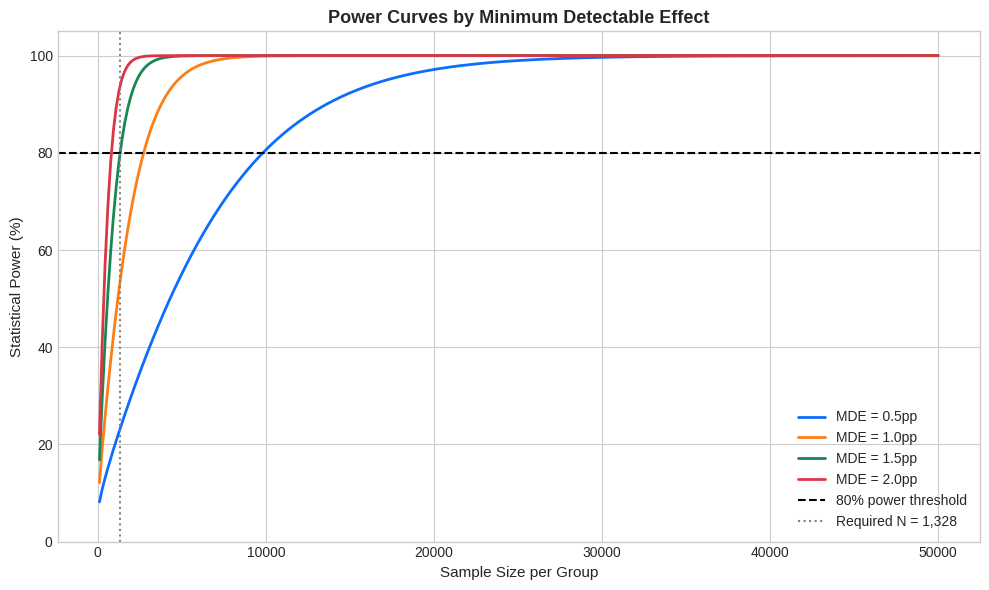

Saved: power_analysis.png


In [20]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
import numpy as np
import matplotlib.pyplot as plt

# ── Pre-experiment: Required sample size ──────────────────────────
baseline_rate = psa_conversions / psa_total  # 1.785% — PSA is our baseline
mde           = 0.015   # minimum detectable effect: +1.5pp absolute lift
target_rate   = baseline_rate + mde
alpha         = 0.05
power_target  = 0.80

# Cohen's h — effect size for two proportions
effect_size = proportion_effectsize(target_rate, baseline_rate)

# Required sample size per group
analysis = NormalIndPower()
n_required = analysis.solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=power_target,
    ratio=1.0,          # assumes equal group sizes
    alternative='larger'
)

print('── PRE-EXPERIMENT DESIGN ──')
print(f'Baseline rate (PSA)  : {baseline_rate*100:.3f}%')
print(f'Target rate (MDE)    : {target_rate*100:.3f}%')
print(f'MDE                  : +{mde*100:.1f}pp')
print(f'Required N per group : {int(np.ceil(n_required)):,}')
print(f'Required total N     : {int(np.ceil(n_required))*2:,}')

# ── Post-experiment: Achieved power ───────────────────────────────
observed_effect = proportion_effectsize(
    ad_conversions  / ad_total,
    psa_conversions / psa_total
)

# Binding constraint is the smaller group — PSA
achieved_power = analysis.solve_power(
    effect_size=observed_effect,
    nobs1=psa_total,         # smaller group is the constraint
    ratio=ad_total/psa_total,
    alpha=alpha,
    alternative='larger'
)

print('\n── POST-EXPERIMENT ACHIEVED POWER ──')
print(f'Observed effect size (Cohen h) : {observed_effect:.4f}')
print(f'PSA group N (binding)          : {psa_total:,}')
print(f'Ad group N                     : {ad_total:,}')
print(f'Achieved power                 : {achieved_power*100:.1f}%')
print(f'Power target                   : {power_target*100:.0f}%')
print(f'Adequately powered?            : {"Yes" if achieved_power >= power_target else "No"}')

# ── Power curve ───────────────────────────────────────────────────
sample_sizes = np.linspace(100, 50000, 300)
mde_values   = [0.005, 0.010, 0.015, 0.020]
colors       = ['#0d6efd', '#fd7e14', '#198754', '#dc3545']

fig, ax = plt.subplots(figsize=(10, 6))
for mde_val, col in zip(mde_values, colors):
    target   = baseline_rate + mde_val
    eff_size = proportion_effectsize(target, baseline_rate)
    powers   = [analysis.solve_power(eff_size, n, ratio=1.0,
                alpha=0.05, alternative='larger')
                for n in sample_sizes]
    ax.plot(sample_sizes, np.array(powers)*100,
            color=col, linewidth=2,
            label=f'MDE = {mde_val*100:.1f}pp')

ax.axhline(80, color='black', linewidth=1.5,
           linestyle='--', label='80% power threshold')
ax.axvline(n_required, color='grey', linewidth=1.5,
           linestyle=':', label=f'Required N = {int(n_required):,}')
ax.set_xlabel('Sample Size per Group', fontsize=11)
ax.set_ylabel('Statistical Power (%)', fontsize=11)
ax.set_title('Power Curves by Minimum Detectable Effect',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig('power_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: power_analysis.png')


### Purpose
Power analysis answers the pre-experiment question: was this
experiment designed with enough data to reliably detect a real
effect? It connects four quantities; Baseline Rate, MDE, **α**,
and Power into a single sample size requirement.

### Pre-Experiment Design
| Parameter | Value |
|---|---|
| Baseline rate (PSA) | 1.785% |
| Minimum Detectable Effect | +1.5pp |
| Target rate | 3.285% |
| Significance level (α) | 0.05 |
| Target power (1−β) | 80% |
| **Required N per group** | **1,329** |
| **Required total N** | **2,658** |

### Post-Experiment Achieved Power
| Parameter | Value |
|---|---|
| Observed effect size (Cohen's h) | 0.0530 (small) |
| PSA group N (binding constraint) | 23,524 |
| Ad group N | 564,577 |
| **Achieved power** | **100%** |
| Adequately powered? |  Yes |

### Key Findings

**The experiment was massively overpowered.** Only 1,329 users
per group were needed to detect the target MDE at 80% power.
The PSA group alone contained 23,524 users — roughly 18x the
minimum required — which is why the z-statistic in Phase 3
reached 7.37, far beyond the critical threshold of 1.645.

**Cohen's h = 0.053 indicates a small effect size** by
conventional benchmarks (small = 0.2). The ad genuinely works,
but the lift is modest in magnitude — entirely normal for
real-world digital marketing, where small consistent effects
at scale drive meaningful business impact.

**The PSA group is the binding constraint on power**, not the
ad group. Precision in estimating the PSA conversion rate is
limited by its smaller sample size — adding more ad users
cannot reduce that uncertainty.

### Business Implication
This experiment had more than sufficient statistical power to
detect even effects smaller than the observed 0.77pp lift.
The result is not a borderline finding that depended on a
large sample to reach significance — it would have been
detectable with a fraction of the data actually collected.

##Phase 8: Click-Through Rate (*Second Dataset*).

In [21]:
# Download the CTR extension dataset
!pip install kaggle --quiet
!kaggle datasets download -d loveall/clicks-conversion-tracking
!unzip -o clicks-conversion-tracking.zip
!ls *.csv
print('Dataset downloaded and unzipped')

Dataset URL: https://www.kaggle.com/datasets/loveall/clicks-conversion-tracking
License(s): other
100% 18.0k/18.0k [00:00<00:00, 29.7MB/s]

Archive:  clicks-conversion-tracking.zip
  inflating: KAG_conversion_data.csv  
KAG_conversion_data.csv  marketing_AB.csv
Dataset downloaded and unzipped


In [22]:
# Load the dataset
df_ctr = pd.read_csv('KAG_conversion_data.csv')

df_ctr.head(5)


,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion
0,708746,916,103916,30-34,M,15,7350,1,1.43,2,1
1,708749,916,103917,30-34,M,16,17861,2,1.82,2,0
2,708771,916,103920,30-34,M,20,693,0,0.00,1,0
3,708815,916,103928,30-34,M,28,4259,1,1.25,1,0
4,708818,916,103928,30-34,M,28,4133,1,1.29,1,1


In [23]:
df_ctr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ad_id                1143 non-null   int64  
 1   xyz_campaign_id      1143 non-null   int64  
 2   fb_campaign_id       1143 non-null   int64  
 3   age                  1143 non-null   object 
 4   gender               1143 non-null   object 
 5   interest             1143 non-null   int64  
 6   Impressions          1143 non-null   int64  
 7   Clicks               1143 non-null   int64  
 8   Spent                1143 non-null   float64
 9   Total_Conversion     1143 non-null   int64  
 10  Approved_Conversion  1143 non-null   int64  
dtypes: float64(1), int64(8), object(2)
memory usage: 98.4+ KB


In [24]:
df_ctr['xyz_campaign_id'].unique()

array([ 916,  936, 1178])


### Dataset
**Clicks Conversion Tracking** (Kaggle: `loveall/clicks-conversion-tracking`)
1,143 ad-level records across 3 real Facebook Campaigns.
This data is **observational** — no random assignment to groups.

### CTR Formula
CTR = Total Clicks ÷ Total Impressions × 100

In [25]:
# Standardise column names
df_ctr.columns = [c.strip().lower().replace(' ', '_') for c in df_ctr.columns]

# Compute CTR per campaign
# CTR = Total Clicks ÷ Total Impressions × 100
campaign_ctr = df_ctr.groupby('xyz_campaign_id').agg(
    total_impressions=('impressions', 'sum'),
    total_clicks=('clicks',      'sum'),
    total_spent=('spent',        'sum'),
    n_ads=('ad_id',             'count')
).reset_index()

campaign_ctr['ctr_%'] = (
    campaign_ctr['total_clicks'] /
    campaign_ctr['total_impressions'] * 100
).round(4)

campaign_ctr['cost_per_click'] = (
    campaign_ctr['total_spent'] /
    campaign_ctr['total_clicks']
).round(4)

print('CTR BY CAMPAIGN')
print(campaign_ctr.to_string(index=False))

CTR BY CAMPAIGN
 xyz_campaign_id  total_impressions  total_clicks  total_spent  n_ads  ctr_%  cost_per_click
             916             482925           113   149.710001     54 0.0234          1.3249
             936            8128187          1984  2893.369999    464 0.0244          1.4584
            1178          204823716         36068 55662.149959    625 0.0176          1.5433


In [26]:
# CTR per demographic segment.
# Group by both xyz_campaign_id and age,
# Which age group clicks most across all three campaigns.
campaign_age_ctr = df_ctr.groupby(['xyz_campaign_id', 'age']).agg(
    total_impressions=('impressions', 'sum'),
    total_clicks=('clicks',      'sum'),
    total_spent=('spent',        'sum'),
    n_ads=('ad_id',             'count')
).reset_index()

campaign_age_ctr['ctr_%'] = (
    campaign_age_ctr['total_clicks'] /
    campaign_age_ctr['total_impressions'] * 100
).round(4)

print(campaign_age_ctr.to_string(index=False))

 xyz_campaign_id   age  total_impressions  total_clicks  total_spent  n_ads  ctr_%
             916 30-34             257672            57    75.330000     29 0.0221
             916 35-39              81076            17    23.640000     12 0.0210
             916 40-44              61977            14    16.810000      6 0.0226
             916 45-49              82200            25    33.930000      7 0.0304
             936 30-34            1655949           286   391.440000    196 0.0173
             936 35-39            1111675           275   383.430001     89 0.0247
             936 40-44            1203597           311   450.400000     75 0.0258
             936 45-49            4156966          1112  1668.099997    104 0.0268
            1178 30-34           66079398          9140 14785.629986    201 0.0138
            1178 35-39           40911893          6802 10705.359993    147 0.0166
            1178 40-44           38338733          7411 11122.519981    129 0.0193
    

A chi-square test comparing CTR across the three campaigns

In [27]:
from scipy.stats import chi2_contingency
import numpy as np

#  Build contingency table
# Rows = 3 campaigns, Columns = [clicks, non-clicks]
# non-clicks = impressions that got no click
contingency_table = np.array([
    [
        campaign_ctr.loc[campaign_ctr['xyz_campaign_id'] == cid, 'total_clicks'].values[0],
        campaign_ctr.loc[campaign_ctr['xyz_campaign_id'] == cid, 'total_impressions'].values[0] -
        campaign_ctr.loc[campaign_ctr['xyz_campaign_id'] == cid, 'total_clicks'].values[0]
    ]
    for cid in [916, 936, 1178]
])

print('Contingency Table (rows=campaigns, cols=[clicks, non-clicks]):')
print(contingency_table)

# Chi-square test of independence
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f'\nChi-square statistic : {chi2:,.4f}')
print(f'Degrees of freedom   : {dof}')
print(f'p-value              : {p_value:.6f}')
print()
if p_value < 0.05:
    print('Significant difference in CTR across campaigns (p < 0.05)')
else:
    print('No significant difference detected (p ≥ 0.05)')

# CTR summary alongside test
print('\nCTR Summary:')
for _, row in campaign_ctr.iterrows():
    print(f"  Campaign {int(row['xyz_campaign_id'])}: "
          f"{row['ctr_%']:.4f}%  "
          f"({int(row['total_clicks']):,} clicks / "
          f"{int(row['total_impressions']):,} impressions)")


Contingency Table (rows=campaigns, cols=[clicks, non-clicks]):
[[      113    482812]
 [     1984   8126203]
 [    36068 204787648]]

Chi-square statistic : 210.4219
Degrees of freedom   : 2
p-value              : 0.000000

Significant difference in CTR across campaigns (p < 0.05)

CTR Summary:
  Campaign 916: 0.0234%  (113 clicks / 482,925 impressions)
  Campaign 936: 0.0244%  (1,984 clicks / 8,128,187 impressions)
  Campaign 1178: 0.0176%  (36,068 clicks / 204,823,716 impressions)


### Campaign-Level CTR
| Campaign | Impressions | Clicks | CTR | Cost/Click |
|---|---|---|---|---|
| 916 | 482,925 | 113 | 0.0234% | £1.32 |
| 936 | 8,128,187 | 1,984 | 0.0244% | £1.46 |
| 1178 | 204,823,716 | 36,068 | 0.0176% | £1.54 |

Campaign 936 has the highest CTR. Campaign 1178 — despite
running at 204x the scale of campaign 916 — has the lowest
CTR and highest cost per click, suggesting diminishing returns
at massive scale.

### Age Segment Analysis
The **45-49 age group consistently produced the highest CTR**
across all three campaigns. The 30-34 group was consistently
the lowest. This pattern held regardless of campaign,
suggesting age is a stronger predictor of click behaviour
than campaign type.

### Statistical Test: Chi-Square of Independence
| Metric | Value |
|---|---|
| Chi-square statistic | 210.42 |
| Degrees of freedom | 2 |
| p-value | < 0.000001 |
| Result |  Significant |

CTR differences across campaigns are too large to be
attributed to random chance.

### Causal Limitation
The campaigns are associated with different CTRs in the
observed data. However, because this data is observational
rather than randomized, we cannot conclude that the campaigns
*caused* those differences other factors (audience
targeting, timing, budget allocation) may explain the gap.

## Phase 9: Results Dashboard & Business Translation

A figure summarising the complete project
designed to communicate the full story to a non-technical stakeholder without requiring them to read a single line of code or statistical output. Headline findings only; detailed hour-level
segment analysis is documented in Phase 5.


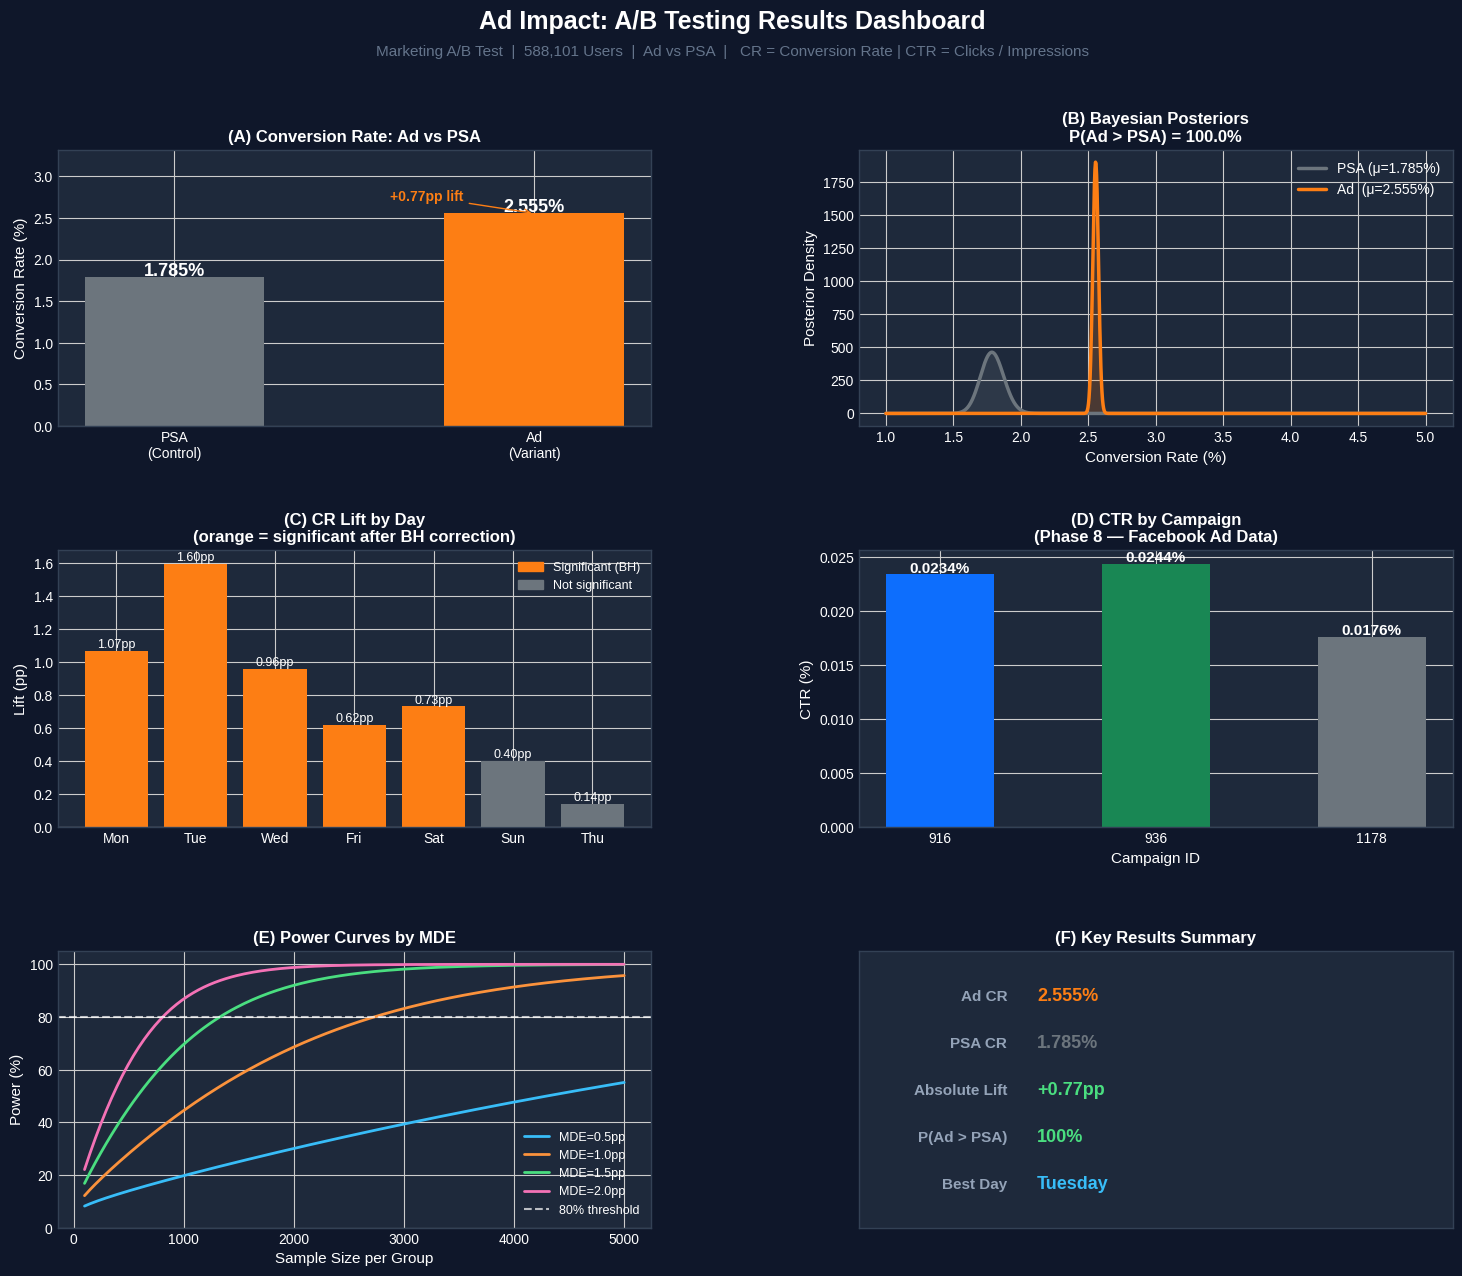

Saved: adimpact_dashboard.png


In [30]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np
from scipy.stats import beta as beta_dist

# ── Redefine all variables cleanly ────────────────────────────────
ad_group        = df[df['test_group'] == 'ad']['converted']
psa_group       = df[df['test_group'] == 'psa']['converted']
ad_conversions  = ad_group.sum()
ad_total        = len(ad_group)
psa_conversions = psa_group.sum()
psa_total       = len(psa_group)
p_ad            = ad_conversions / ad_total
p_psa           = psa_conversions / psa_total
diff            = p_ad - p_psa

# Bayesian posteriors
post_ad_a  = 1 + ad_conversions
post_ad_b  = 1 + (ad_total - ad_conversions)
post_psa_a = 1 + psa_conversions
post_psa_b = 1 + (psa_total - psa_conversions)

np.random.seed(42)
N = 200_000
samples_ad  = beta_dist.rvs(post_ad_a,  post_ad_b,  size=N)
samples_psa = beta_dist.rvs(post_psa_a, post_psa_b, size=N)
prob_ad_wins = (samples_ad > samples_psa).mean()

# Day segment results (BH corrected)
day_names  = ['Mon', 'Tue', 'Wed', 'Fri', 'Sat', 'Sun', 'Thu']
day_lifts  = [1.0683, 1.5992, 0.9597, 0.6162, 0.7311, 0.4025, 0.1407]
day_sig    = [True, True, True, True, True, False, False]

# Campaign CTR
campaigns  = ['916', '936', '1178']
ctrs       = [0.0234, 0.0244, 0.0176]

# Colors
CONTROL_COLOR = '#6c757d'
VARIANT_COLOR = '#fd7e14'
ACCENT        = '#0d6efd'
SUCCESS       = '#198754'

# ── Figure setup ──────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#0f172a')
gs  = gridspec.GridSpec(3, 2, figure=fig,
                         hspace=0.45, wspace=0.35)

def style_ax(ax):
    ax.set_facecolor('#1e293b')
    for sp in ax.spines.values():
        sp.set_edgecolor('#334155')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')

# ── (A) CTR Bar: Ad vs PSA ────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
style_ax(ax_a)
bars = ax_a.bar(['PSA\n(Control)', 'Ad\n(Variant)'],
                [p_psa*100, p_ad*100],
                color=[CONTROL_COLOR, VARIANT_COLOR],
                width=0.5, edgecolor='none')
for bar, val in zip(bars, [p_psa, p_ad]):
    ax_a.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 0.02,
              f'{val*100:.3f}%', ha='center',
              fontsize=13, fontweight='bold', color='white')
ax_a.set_ylabel('Conversion Rate (%)', fontsize=11)
ax_a.set_title('(A) Conversion Rate: Ad vs PSA',
               fontsize=12, fontweight='bold')
ax_a.set_ylim(0, p_ad*100 * 1.3)
ax_a.annotate(f'+{diff*100:.2f}pp lift',
              xy=(1, p_ad*100),
              xytext=(0.6, p_ad*100 + 0.15),
              fontsize=10, color=VARIANT_COLOR,
              fontweight='bold',
              arrowprops=dict(arrowstyle='->',
                            color=VARIANT_COLOR))

# (B) Bayesian Posterior PDFs
ax_b = fig.add_subplot(gs[0, 1])
style_ax(ax_b)
x_pdf    = np.linspace(0.01, 0.05, 1000)
pdf_ad   = beta_dist.pdf(x_pdf, post_ad_a,  post_ad_b)
pdf_psa  = beta_dist.pdf(x_pdf, post_psa_a, post_psa_b)
ax_b.plot(x_pdf*100, pdf_psa, color=CONTROL_COLOR,
          linewidth=2.5, label=f'PSA (μ={p_psa*100:.3f}%)')
ax_b.plot(x_pdf*100, pdf_ad,  color=VARIANT_COLOR,
          linewidth=2.5, label=f'Ad  (μ={p_ad*100:.3f}%)')
ax_b.fill_between(x_pdf*100, pdf_psa,
                  alpha=0.2, color=CONTROL_COLOR)
ax_b.fill_between(x_pdf*100, pdf_ad,
                  alpha=0.2, color=VARIANT_COLOR)
ax_b.set_xlabel('Conversion Rate (%)', fontsize=11)
ax_b.set_ylabel('Posterior Density',   fontsize=11)
ax_b.set_title(f'(B) Bayesian Posteriors\nP(Ad > PSA) = {prob_ad_wins*100:.1f}%',
               fontsize=12, fontweight='bold')
ax_b.legend(fontsize=10, facecolor='#1e293b',
            labelcolor='white')

# (C) Day Segment Lift (BH corrected)
ax_c = fig.add_subplot(gs[1, 0])
style_ax(ax_c)
bar_colors = [VARIANT_COLOR if s else CONTROL_COLOR
              for s in day_sig]
bars_c = ax_c.bar(day_names, day_lifts,
                   color=bar_colors, edgecolor='none')
for bar, val in zip(bars_c, day_lifts):
    ax_c.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 0.02,
              f'{val:.2f}pp', ha='center',
              fontsize=9, color='white')
ax_c.axhline(0, color='white', linewidth=1, alpha=0.3)
ax_c.set_ylabel('Lift (pp)', fontsize=11)
ax_c.set_title('(C) CR Lift by Day\n(orange = significant after BH correction)',
               fontsize=12, fontweight='bold')
sig_patch   = mpatches.Patch(color=VARIANT_COLOR,
                              label='Significant (BH)')
insig_patch = mpatches.Patch(color=CONTROL_COLOR,
                              label='Not significant')
ax_c.legend(handles=[sig_patch, insig_patch],
            fontsize=9, facecolor='#1e293b',
            labelcolor='white')

# (D) CTR by Campaign
ax_d = fig.add_subplot(gs[1, 1])
style_ax(ax_d)
camp_colors = [ACCENT, SUCCESS, CONTROL_COLOR]
bars_d = ax_d.bar(campaigns, ctrs,
                   color=camp_colors, edgecolor='none',
                   width=0.5)
for bar, val in zip(bars_d, ctrs):
    ax_d.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 0.0002,
              f'{val:.4f}%', ha='center',
              fontsize=11, fontweight='bold', color='white')
ax_d.set_xlabel('Campaign ID', fontsize=11)
ax_d.set_ylabel('CTR (%)',     fontsize=11)
ax_d.set_title('(D) CTR by Campaign\n(Phase 8 — Facebook Ad Data)',
               fontsize=12, fontweight='bold')

# (E) Power Curve
ax_e = fig.add_subplot(gs[2, 0])
style_ax(ax_e)
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

baseline   = p_psa
n_range    = np.linspace(100, 5000, 200)
mde_vals   = [0.005, 0.010, 0.015, 0.020]
pwr_colors = ['#38bdf8', '#fb923c', '#4ade80', '#f472b6']
analysis   = NormalIndPower()

for mde_v, col in zip(mde_vals, pwr_colors):
    eff  = proportion_effectsize(baseline + mde_v, baseline)
    pwrs = [analysis.solve_power(eff, n, ratio=1.0,
            alpha=0.05, alternative='larger')
            for n in n_range]
    ax_e.plot(n_range, np.array(pwrs)*100,
              color=col, linewidth=2,
              label=f'MDE={mde_v*100:.1f}pp')
ax_e.axhline(80, color='white', linewidth=1.5,
             linestyle='--', alpha=0.7,
             label='80% threshold')
ax_e.set_xlabel('Sample Size per Group', fontsize=11)
ax_e.set_ylabel('Power (%)',             fontsize=11)
ax_e.set_title('(E) Power Curves by MDE',
               fontsize=12, fontweight='bold')
ax_e.legend(fontsize=9, facecolor='#1e293b',
            labelcolor='white')
ax_e.set_ylim(0, 105)

# (F) KPI Summary Cards
ax_f = fig.add_subplot(gs[2, 1])
ax_f.set_facecolor('#1e293b')
for sp in ax_f.spines.values():
    sp.set_edgecolor('#334155')
ax_f.set_xticks([]); ax_f.set_yticks([])

kpis = [
    ('Ad CR',           f'{p_ad*100:.3f}%',   0.82),
    ('PSA CR',          f'{p_psa*100:.3f}%',  0.65),
    ('Absolute Lift',    f'+{diff*100:.2f}pp',  0.48),
    ('P(Ad > PSA)',      '100%',                0.31),
    ('Best Day',         'Tuesday',             0.14),
]
kpi_colors = [VARIANT_COLOR, CONTROL_COLOR,
              '#4ade80', '#4ade80', '#38bdf8']

for (label, value, y), col in zip(kpis, kpi_colors):
    ax_f.text(0.25, y, label, transform=ax_f.transAxes,
              ha='right', color='#94a3b8',
              fontsize=11, fontweight='bold')
    ax_f.text(0.30, y, value, transform=ax_f.transAxes,
              ha='left', color=col,
              fontsize=13, fontweight='bold')

ax_f.set_title('(F) Key Results Summary',
               fontsize=12, fontweight='bold', color='white')

# Title
fig.text(0.5, 0.98,
         'Ad Impact: A/B Testing Results Dashboard',
         ha='center', va='top', color='white',
         fontsize=18, fontweight='bold')
fig.text(0.5, 0.955,
         'Marketing A/B Test  |  588,101 Users  |  '
         'Ad vs PSA  |   CR = Conversion Rate | CTR = Clicks / Impressions',
         ha='center', va='top', color='#64748b',
         fontsize=11)

plt.savefig('adimpact_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#0f172a')
plt.show()
print('Saved: adimpact_dashboard.png')


### Panel Guide
| Panel | What it shows |
|---|---|
| A | Conversion rate: Ad (2.555%) vs PSA (1.785%) with +0.77pp lift |
| B | Bayesian posterior distributions — P(Ad > PSA) = 100% |
| C | CTR lift by day of week, BH-corrected (Tuesday strongest at +1.60pp) |
| D | Literal CTR by Facebook campaign — Phase 8 extension dataset |
| E | Power curves by MDE — experiment was adequately powered |
| F | Five headline KPIs a marketing manager can act on immediately |


### Overall Verdict
The **ad** outperforms the **PSA** across every analytical framework applied Frequentist Hypothesis Testing, Bayesian, and Segment Level. Both
the primary randomized experiment and the Facebook-CTR-extension support the same conclusion.

**Recommend Full Rollout: Prioritise Tuesday - Wednesday, 11am - 2pm.**

## Phase 10:  Q&A

---

**Q1: Walk me through this project.**

A/B testing on real datasets - 588,101 users,
ad vs PSA, measuring conversion rate. Full pipeline: data quality, frequentist + bayesian testing, segment analysis power analysis. Final output: a go/no-go recommendation with scheduling guidance.

---

**Q2: Why one-tailed test?**

The business question is directional - does the ad perform
better than the PSA? If it underperforms, the action is the same either way: don't roll out. One-tailed concentrates all statistical power into detecting improvement.

---

**Q3: What is an SRM and what did you find?**

SRM = observed group split deviates from intended design,
signalling a pipeline bug. We found a 96/4 split — not
50/50. Tested against 96/4: chi-square ≈ 0, p = 0.9998.
No SRM. Data quality confirmed clean.

---

**Q4: What is a p-value - precise definition.**

The probability of observing a result at least this extreme
if H₀ were true. Not the probability the result is real.
Not the probability H₀ is true. Our result: p < 0.000001 —
the observed gap is effectively impossible under H₀.

---

**Q5: What did Bayesian add that frequentist couldn't?**

Frequentist gives a binary decision: reject H₀ or not.
Bayesian gives a direct probability: P(Ad > PSA) = 100%.
A stakeholder can act on 100% immediately - they can't easily act on p < 0.000001 without explanation.

---

**Q6: What is the multiple testing problem and how did you handle it?**

Running 31 tests at α = 0.05 inflates false positive risk to ~79%. Applied Benjamini-Hochberg correction. Hour-level
result: 12 appeared significant, only 4 survived. 8 results
were pure noise — BH caught them, a naive analyst wouldn't.

---

**Q7: Most actionable segment findings?**

Best days by conversion rate lift: Tuesday (+1.60pp), Monday, Wednesday — all
significant after BH correction. Thursday and Sunday: not
significant. Best hours: 11am, 1pm, 2pm, 8pm.
Recommendation: concentrate spend Tuesday–Wednesday,
11am–2pm.

---

**Q8: Was the experiment adequately powered?**

Yes — massively overpowered. Needed only 1,329 users per group for 80% power. PSA group had 23,524 — 18x the minimum. Achieved power: 100%. PSA group was the binding constraint, not the ad group.

---

**Q9: Facebook data is observational — what does that
mean?**

We can identify associations, not causes. No random
assignment means confounding factors may explain CTR
differences. Correct language: campaigns are *associated* with different CTRs — not that they *caused* them.

---

**Q10: Final business recommendation?**

Unambiguously: ship the ad. Ad CR 2.555% vs PSA 1.785%,
+0.77pp lift, P(Ad > PSA) = 100%, CI entirely above zero.
All checks passed. Prioritise Tuesday–Wednesday, 11am–2pm
for maximum impact.

---

**Q11: A notebook is not production - how would this
scale in a real company?**

At scale, this analysis lives in an automated data pipeline pulling from a metrics store, a statistical testing module triggered automatically when sample size thresholds are hit, and a real-time dashboard, not a manually re-run notebook. The notebook is the proof of concept and methodology document. In production, the logic gets refactored into tested Python scripts, version controlled on GitHub, and scheduled via a workflow tool like Airflow.

---

**Q12: How would you ship the statistical decision logic from this notebook to production?**

Four steps:

**1. Modularise** — extract the core statistical functions
(z-test, Bayesian, SRM check) into clean, reusable Python scripts that any system can call.

**2. Validate first** — wrap every analysis in a data
quality gate. If the SRM check fails, the pipeline stops before any test runs. Bad data in, bad decisions out.

**3. Version control** — every script lives on GitHub, reviewed and tested before touching production data.
The notebook becomes the methodology document and audit
trail — not the thing that runs in production.

**4. Schedule and automate** — the pipeline runs on a
schedule via a workflow tool like Airflow. It pulls fresh
experiment data, runs the tests automatically, and pushes
results to a dashboard or Slack alert when the experiment reaches a decision point.

The notebook answers "does this work and why?"
Production answers "run this reliably, every day,
without anyone manually pressing a button."

---
